<a href="https://colab.research.google.com/github/Sarthak3144/Decepticons_-Network-Graph-Intelligence/blob/main/ExploratoryDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

In [15]:
#Setting up styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [16]:
#Loading datasets
print("Loading datasets")
tx_df = pd.read_csv('transactions.csv')
accounts_df = pd.read_csv('accounts.csv')
edges_df = pd.read_csv('graph_edges.csv')
ml_features_df = pd.read_csv('ml_features.csv')
print("Loading successful")

Loading datasets
Loading successful


In [17]:
#Dataset Overview (Row, Column Counts & Data Types)
datasets = {
    "Transactions": tx_df,
    "Accounts (KYC)": accounts_df,
    "Graph Edges": edges_df,
    "ML Features": ml_features_df
}
print("Dataset Overview")


for name, df in datasets.items():
    print(f"\n{name} Dataset Details:")
    print(f"Total Rows: {df.shape[0]:,}")
    print(f"Total Columns: {df.shape[1]}")
    print("Data Types:")
    print(df.dtypes.value_counts())
    print("-" * 30)

Dataset Overview

Transactions Dataset Details:
Total Rows: 100,222
Total Columns: 55
Data Types:
int64      25
object     20
float64    10
Name: count, dtype: int64
------------------------------

Accounts (KYC) Dataset Details:
Total Rows: 65,339
Total Columns: 13
Data Types:
object    8
int64     4
bool      1
Name: count, dtype: int64
------------------------------

Graph Edges Dataset Details:
Total Rows: 100,222
Total Columns: 6
Data Types:
int64      3
object     2
float64    1
Name: count, dtype: int64
------------------------------

ML Features Dataset Details:
Total Rows: 100,222
Total Columns: 35
Data Types:
int64      25
float64     8
object      2
Name: count, dtype: int64
------------------------------


In [18]:
#Missing Value Analysis and Data Quality Check
print("Missing Value Analysis")
print("=" * 30)
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

    if not missing_df.empty:
        print(f"\nMissing data found in '{name}':")
        print(missing_df)
    else:
        print(f"\nNo missing values found in '{name}'.")

print("\nData Quality Health Check")
print("=" * 30)

# 1. Negative amounts check
neg_tx = (tx_df['amount_local_npr'] < 0).sum()
print(f"Transactions with negative NPR amounts: {neg_tx}")

# 2. Graph integrity check: Do all edge accounts exist in KYC?
edge_senders = set(edges_df['Sender_account'].unique())
edge_receivers = set(edges_df['Receiver_account'].unique())
all_edge_nodes = edge_senders.union(edge_receivers)
kyc_nodes = set(accounts_df['account_id'].unique())

missing_kyc = len(all_edge_nodes - kyc_nodes)
print(f"Active graph accounts missing from KYC registry: {missing_kyc}")

Missing Value Analysis

No missing values found in 'Transactions'.

No missing values found in 'Accounts (KYC)'.

No missing values found in 'Graph Edges'.

No missing values found in 'ML Features'.

Data Quality Health Check
Transactions with negative NPR amounts: 0
Active graph accounts missing from KYC registry: 0


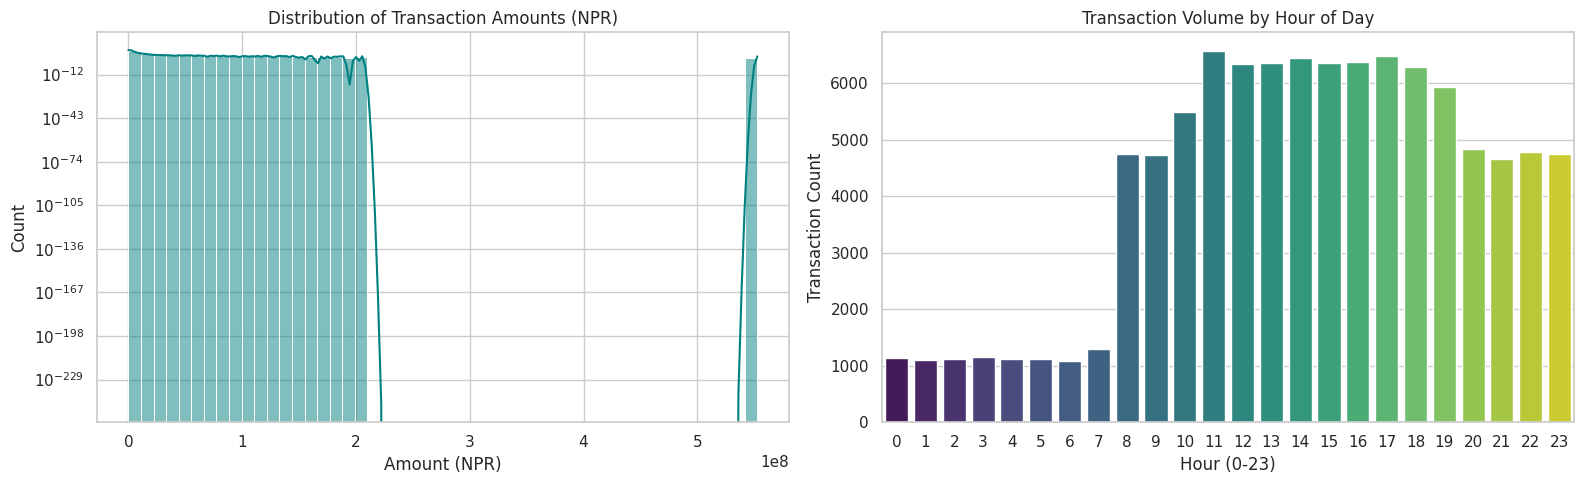

In [19]:
# Feature Distribution (Transactions Amount and Timing)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Distribution of transaction sizes
sns.histplot(tx_df['amount_local_npr'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Transaction Amounts (NPR)')
axes[0].set_xlabel('Amount (NPR)')
axes[0].set_yscale('log') # Log scale because money laundering data has extreme outliers

# Plot 2: Hourly pattern of transactions
sns.countplot(data=tx_df, x='hour_of_day', palette='viridis', ax=axes[1])
axes[1].set_title('Transaction Volume by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Transaction Count')

plt.tight_layout()
plt.show()

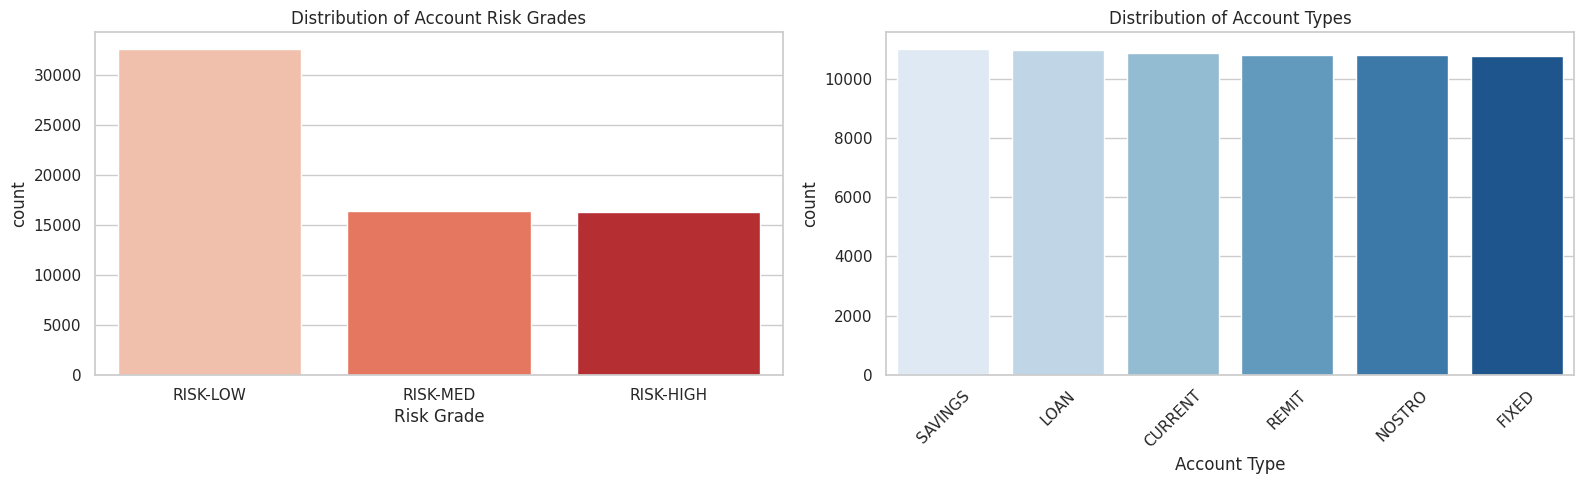

In [20]:
# Node level Distributions (Risck Grades and Account types)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Account Risk Profiles
sns.countplot(data=accounts_df, x='risk_grade', order=['RISK-LOW', 'RISK-MED', 'RISK-HIGH'], palette='Reds', ax=axes[0])
axes[0].set_title('Distribution of Account Risk Grades')
axes[0].set_xlabel('Risk Grade')

# Plot 2: Types of accounts
sns.countplot(data=accounts_df, x='acct_type', order=accounts_df['acct_type'].value_counts().index, palette='Blues', ax=axes[1])
axes[1].set_title('Distribution of Account Types')
axes[1].set_xlabel('Account Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

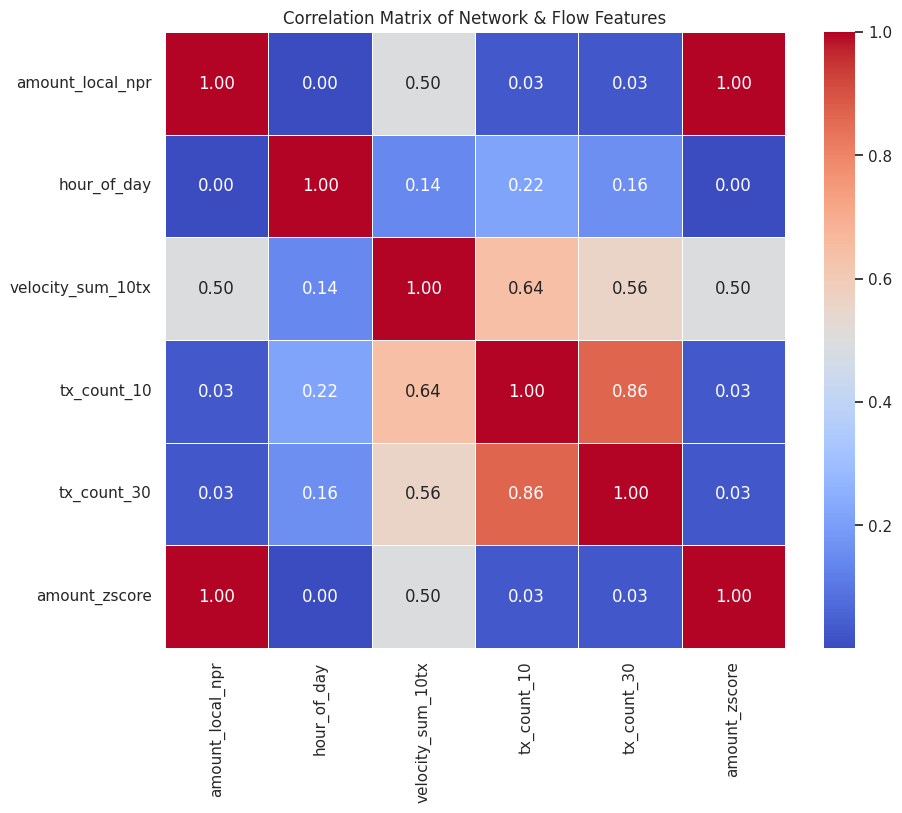

In [21]:
# Correlations and Key Feature Relationships

# Selecting numerical columns that are highly relevant to AML tracking
corr_cols = ['amount_local_npr', 'hour_of_day', 'velocity_sum_10tx', 'tx_count_10', 'tx_count_30', 'amount_zscore']

# Filtering columns that exist in the transaction dataset
existing_corr_cols = [c for c in corr_cols if c in tx_df.columns]

plt.figure(figsize=(10, 8))
corr_matrix = tx_df[existing_corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Network & Flow Features')
plt.show()

In [22]:
# Network Specific Baseline Insights

print("Baseline Graph Insights")
print("=" * 30)

# Computing basic degree distributions using pandas for quickness
send_counts = edges_df['Sender_account'].value_counts()
receive_counts = edges_df['Receiver_account'].value_counts()

print(f"Total Unique Senders: {len(send_counts):,}")
print(f"Total Unique Receivers: {len(receive_counts):,}")

print("\nTop Fan-Out Accounts (Potential Senders / Smurfing):")
print(send_counts.head(5))

print("\nTop Fan-In Accounts (Potential Receivers / Collectors):")
print(receive_counts.head(5))

# Accounts that both send and receive (Potential Layering / pass-through accounts)
layering_candidates = set(send_counts.index).intersection(set(receive_counts.index))
print(f"\nAccounts acting as both Senders & Receivers (Pass-through / Layering candidates): {len(layering_candidates):,}")

Baseline Graph Insights
Total Unique Senders: 22,310
Total Unique Receivers: 46,586

Top Fan-Out Accounts (Potential Senders / Smurfing):
Sender_account
8976725341    265
382301928     264
15297964      263
1452170043    262
7658664999    262
Name: count, dtype: int64

Top Fan-In Accounts (Potential Receivers / Collectors):
Receiver_account
6086421020    241
9683990807    241
464342049     240
7099141711    240
5251195293    240
Name: count, dtype: int64

Accounts acting as both Senders & Receivers (Pass-through / Layering candidates): 3,557


Advanced Graph Intelligence: Amount Conservation Paths
Analysis Results:
Detected 4481 instances of strict multi-hop amount conservation.
This indicates funds passed to a middleman and were subsequently swept to a third account nearly intact.

Sample High-Risk Layering Chains Found:
 Sender_account_hop1  Receiver_account_hop1  Receiver_account_hop2  amount_local_npr_hop1  amount_local_npr_hop2  amount_ratio
          9119143782             1576773608             3880609685              939592.23              895955.36      0.953558
          3139337800             8817936053             7070455925              662906.61              662906.61      1.000000
          3373148945             6034997194             9716991603             4414373.91             4491467.98      1.017464
          1805171806             1465487567             6956716334             1219913.74             1178179.13      0.965789
          3396853729             4293580479             1971949846             53

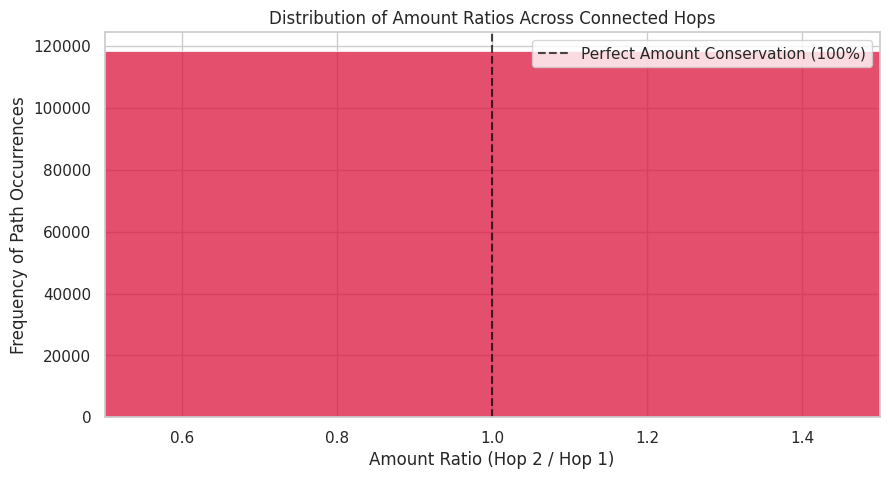

In [23]:

print("Advanced Graph Intelligence: Amount Conservation Paths")
print("=" * 50)

# We want to find cases where Account A -> Account B (Amount X) and then Account B -> Account C (Amount Y)
# where Amount Y is very close to Amount X (e.g., within 5%), indicating a layering chain.

# Step 1: Merging transactions with itself to track sequential flows from a middleman (Receiver who becomes a Sender)
flow_df = tx_df.merge(
    tx_df,
    left_on='Receiver_account',
    right_on='Sender_account',
    suffixes=('_hop1', '_hop2')
)

# Step 2: Applying Domain Rules
# Rule A: Hop 2 must happen around or after Hop 1 (sequential timing or rapid automation)
# Rule B: Amount conservation (The middleman forwards between 95% and 100% of the money to obscure trails)
flow_df['amount_ratio'] = flow_df['amount_local_npr_hop2'] / flow_df['amount_local_npr_hop1']

layering_chains = flow_df[
    (flow_df['amount_ratio'] >= 0.95) &
    (flow_df['amount_ratio'] <= 1.05) &
    (flow_df['Sender_account_hop1'] != flow_df['Receiver_account_hop2']) # Exclude simple back-and-forth pairs
]

print("Analysis Results:")
print(f"Detected {len(layering_chains)} instances of strict multi-hop amount conservation.")
print("This indicates funds passed to a middleman and were subsequently swept to a third account nearly intact.\n")

# Step 3: Displaying the top suspicious multi-hop structural paths found
if not layering_chains.empty:
    print("Sample High-Risk Layering Chains Found:")
    display_cols = ['Sender_account_hop1', 'Receiver_account_hop1', 'Receiver_account_hop2',
                    'amount_local_npr_hop1', 'amount_local_npr_hop2', 'amount_ratio']
    print(layering_chains[display_cols].head(5).to_string(index=False))
else:
    print("No direct 2-hop strict conservation paths found with current thresholds.")

# Step 4: Visualizing the Flow Leakage Distribution
plt.figure(figsize=(10, 5))
sns.histplot(flow_df['amount_ratio'], bins=100, color='crimson', kde=False)
plt.axvline(1.0, color='black', linestyle='--', alpha=0.7, label='Perfect Amount Conservation (100%)')
plt.xlim(0.5, 1.5)
plt.title('Distribution of Amount Ratios Across Connected Hops')
plt.xlabel('Amount Ratio (Hop 2 / Hop 1)')
plt.ylabel('Frequency of Path Occurrences')
plt.legend()
plt.show()

In [24]:
print("Final EDA Deliverable: Target Anomaly Registry")
print("=" * 50)

# Isolating the exact accounts that form the perfect 1.0 ratio spike
perfect_loops = layering_chains[
    (layering_chains['amount_ratio'] >= 0.99) &
    (layering_chains['amount_ratio'] <= 1.01)
]

# Extracting unique accounts involved in these structural chains
flagged_senders = perfect_loops['Sender_account_hop1'].unique()
flagged_hubs = perfect_loops['Receiver_account_hop1'].unique()
flagged_receivers = perfect_loops['Receiver_account_hop2'].unique()

all_flagged_accounts = set(flagged_senders).union(set(flagged_hubs)).union(set(flagged_receivers))

print(f"Total High-Risk Accounts Identified Structurally: {len(all_flagged_accounts)}")
print(f"Layering Sources: {len(flagged_senders)}")
print(f"Pass-Through Laundering Hubs: {len(flagged_hubs)}")
print(f"Final Beneficiary Collectors: {len(flagged_receivers)}\n")

# Mapping back to KYC records to see if these accounts share high-risk profiles
flagged_kyc = accounts_df[accounts_df['account_id'].isin(all_flagged_accounts)]

print("Risk Profile Breakdown of Structurally Flagged Accounts:")
print(flagged_kyc['risk_grade'].value_counts())

# Saving this to a CSV so your teammates can load it instantly for modeling
flagged_kyc.to_csv('eda_flagged_suspicious_accounts.csv', index=False)
print("\nSaved 'eda_flagged_suspicious_accounts.csv' successfully.")

Final EDA Deliverable: Target Anomaly Registry
Total High-Risk Accounts Identified Structurally: 838
Layering Sources: 294
Pass-Through Laundering Hubs: 267
Final Beneficiary Collectors: 285

Risk Profile Breakdown of Structurally Flagged Accounts:
risk_grade
RISK-LOW     422
RISK-HIGH    223
RISK-MED     193
Name: count, dtype: int64

Saved 'eda_flagged_suspicious_accounts.csv' successfully.
